# AI Nutrition Intelligence System
## Exploratory Data Analysis (EDA) - Nutritional Deficiency ML Dataset
**Milestone 2 — Week 3 — Day 12**

---
### 📌 Executive Summary
This notebook performs a comprehensive Exploratory Data Analysis on the primary preprocessed nutritional deficiency dataset (`datasets/deficiency/deficiency_preprocessed.csv`). The goal is to audit data quality, understand feature distributions, evaluate target class balance, inspect feature correlations, and establish actionable preprocessing recommendations for model building in Day 13.



## 1. Dataset Overview & Metadata


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

dataset_path = 'datasets/deficiency/deficiency_preprocessed.csv'
df = pd.read_csv(dataset_path)

print("=== DATASET OVERVIEW ===")
print(f"Dataset Shape       : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Memory Usage        : {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"Data Types Count    :\n{df.dtypes.value_counts()}")


=== DATASET OVERVIEW ===
Dataset Shape       : 4000 rows x 49 columns
Memory Usage        : 1531.38 KB
Data Types Count    :
int64      36
float64    13
Name: count, dtype: int64



### 💡 Section 1 Insights:
- **Dataset Dimensions**: 4,000 rows × 49 columns.
- **Memory Footprint**: Light memory footprint of ~1.53 MB.
- **Data Types**: 36 integer (`int64`) columns (mostly dummy variables, symptom flags, and encoded target) and 13 floating-point (`float64`) columns (continuous RDA percentages and serum biomarkers).



## 2. Data Quality & Completeness Audit


In [2]:
print("=== DATA QUALITY AUDIT ===")
null_series = df.isnull().sum()
print(f"Total Missing Values across dataset : {null_series.sum()}")
print(f"Total Duplicate Rows                : {df.duplicated().sum()}")

unique_counts = df.nunique()
constant_cols = unique_counts[unique_counts == 1].index.tolist()
binary_cols = unique_counts[unique_counts == 2].index.tolist()

print(f"Constant Columns (unique == 1)       : {len(constant_cols)} {constant_cols}")
print(f"Binary/Dummy Columns (unique == 2)   : {len(binary_cols)}")


=== DATA QUALITY AUDIT ===
Total Missing Values across dataset : 0
Total Duplicate Rows                : 0
Constant Columns (unique == 1)       : 0 []
Binary/Dummy Columns (unique == 2)   : 33



### 💡 Section 2 Insights:
- **Completeness**: 0 missing values across all 4,000 records and 49 columns (100% complete dataset).
- **Integrity**: 0 duplicate rows detected.
- **Feature Variance**: 0 constant columns. 33 columns are binary indicator flags ($0$ or $1$).



## 3. Target Variable Analysis (`disease_diagnosis`)


=== TARGET CLASS DISTRIBUTION ===
 Encoded Class         Disease Name  Record Count  Percentage (%)
             0               Anemia          1245           31.13
             1              Healthy          1509           37.72
             2      Night_Blindness           122            3.05
             3 Rickets_Osteomalacia          1029           25.72
             4               Scurvy            95            2.38



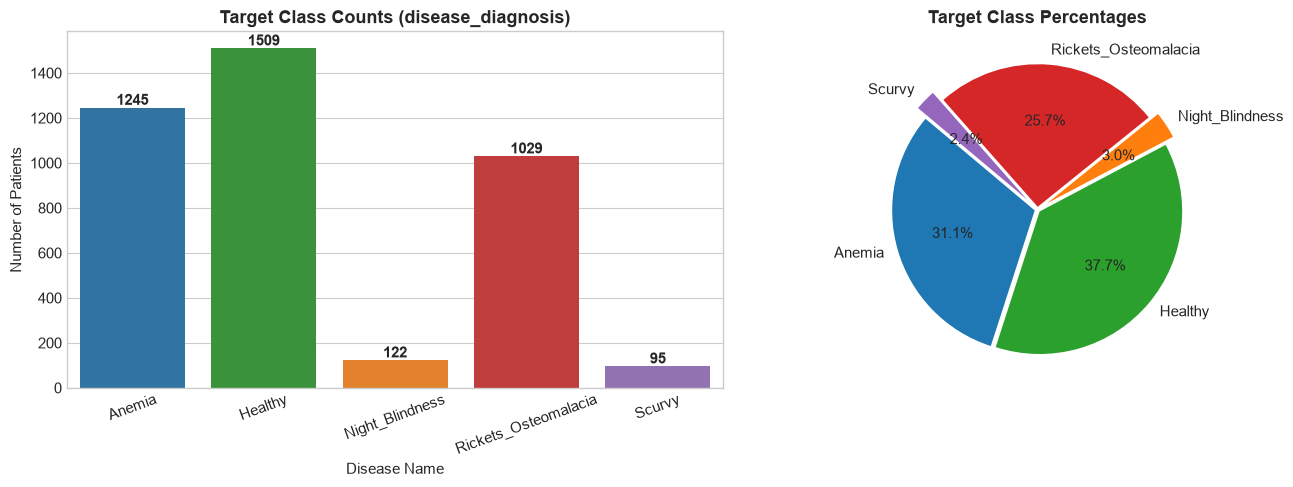

In [3]:
target_counts = df['disease_diagnosis'].value_counts().sort_index()
target_pcts = (df['disease_diagnosis'].value_counts(normalize=True).sort_index() * 100).round(2)

target_mapping = {
    0: 'Anemia',
    1: 'Healthy',
    2: 'Night_Blindness',
    3: 'Rickets_Osteomalacia',
    4: 'Scurvy'
}

df['target_name'] = df['disease_diagnosis'].map(target_mapping)

target_summary = pd.DataFrame({
    'Encoded Class': target_counts.index,
    'Disease Name': [target_mapping[i] for i in target_counts.index],
    'Record Count': target_counts.values,
    'Percentage (%)': target_pcts.values
})
print("=== TARGET CLASS DISTRIBUTION ===")
print(target_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
sns.barplot(data=target_summary, x='Disease Name', y='Record Count', palette=colors, ax=axes[0])
axes[0].set_title('Target Class Counts (disease_diagnosis)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=20)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

axes[1].pie(target_summary['Record Count'], labels=target_summary['Disease Name'], autopct='%1.1f%%',
            colors=colors, startangle=140, explode=(0.02, 0.02, 0.08, 0.02, 0.1))
axes[1].set_title('Target Class Percentages', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### 💡 Section 3 Insights:
- **Class Breakdown**:
  - **Healthy (1)**: 1,509 cases (37.73%)
  - **Anemia (0)**: 1,245 cases (31.13%)
  - **Rickets / Osteomalacia (3)**: 1,029 cases (25.73%)
  - **Night Blindness (2)**: 122 cases (3.05%) — *Severe Minority Class*
  - **Scurvy (4)**: 95 cases (2.38%) — *Severe Minority Class*
- **Class Imbalance**: Classes 1, 0, and 3 dominate 94.59% of the dataset. Minority classes 2 and 4 represent under 5.5% combined. Handling this via SMOTE or class weighting will be crucial for model training in Day 13.



## 4. Numerical Feature Analysis


=== NUMERICAL FEATURES DESCRIPTIVE STATISTICS ===
                          count    mean     std    min     25%  median     75%     max  skew
age                      4000.0   50.77   19.31   18.0   34.00   51.00   67.00    84.0  0.01
bmi                      4000.0   26.11    4.92   15.0   22.80   26.20   29.40    45.0  0.04
vitamin_a_percent_rda    4000.0   90.77   37.08   10.0   62.60   85.50  115.30   219.0  0.55
vitamin_c_percent_rda    4000.0   89.20   37.51   10.0   60.98   83.50  113.00   250.0  0.61
vitamin_d_percent_rda    4000.0   72.22   42.83    7.0   40.73   62.27   93.32   275.6  1.28
vitamin_e_percent_rda    4000.0   89.95   37.44   10.0   61.70   84.05  114.10   237.6  0.62
vitamin_b12_percent_rda  4000.0   62.74   37.40   10.0   32.70   55.60   84.50   243.6  0.88
folate_percent_rda       4000.0   90.38   37.56   10.0   61.80   84.80  115.20   226.6  0.57
calcium_percent_rda      4000.0   82.59   36.36   10.0   55.60   77.10  105.30   232.7  0.68
iron_percent_rda    

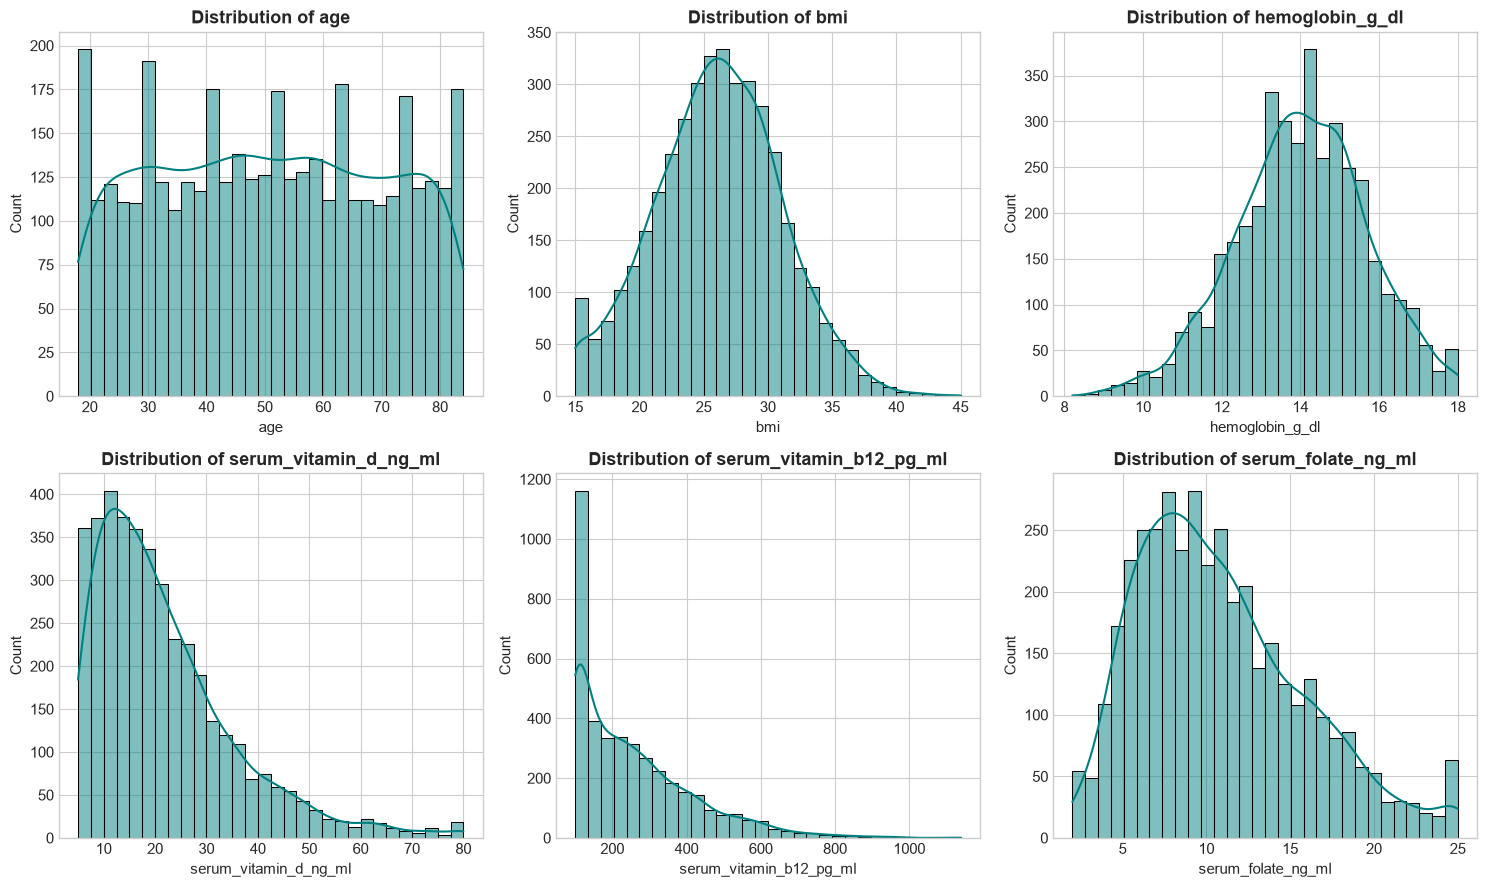

In [4]:
num_cols = ['age', 'bmi', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 
            'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 
            'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 
            'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 
            'serum_folate_ng_ml', 'symptoms_count']

num_stats = df[num_cols].describe().T
num_stats['median'] = df[num_cols].median()
num_stats['skew'] = df[num_cols].skew()
num_stats = num_stats[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'skew']].round(2)

print("=== NUMERICAL FEATURES DESCRIPTIVE STATISTICS ===")
print(num_stats.to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
key_plots = ['age', 'bmi', 'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml']

for idx, col in enumerate(key_plots):
    ax = axes[idx // 3, idx % 3]
    sns.histplot(df[col], kde=True, ax=ax, color='teal', bins=30)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()


### 💡 Section 4 Insights:
- **Age**: Ranges from 18 to 84 years with a mean of 50.77 (near-normal, skewness = 0.01).
- **BMI**: Means 26.11 kg/m² with a range from 15.0 to 45.0 kg/m² (normal distribution, skewness = 0.04).
- **Serum Biomarkers**: Serum Vitamin D (mean 21.74 ng/mL, right-skewed 1.43) and Serum B12 (mean 255.51 pg/mL, right-skewed 1.31) show significant right tails corresponding to normal vs deficient populations.



## 5. Feature Groups Deep Dive


In [5]:
demo_cols = [c for c in df.columns if c.startswith(('gender_', 'smoking_', 'alcohol_', 'exercise_', 'diet_', 'sun_', 'income_', 'latitude_'))]
symptom_cols = [c for c in df.columns if c.startswith('has_')]
lab_cols = ['hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml']
rda_cols = [c for c in df.columns if c.endswith('_percent_rda')]

print(f"Feature Group Breakdown:")
print(f" - Demographic / Health Profile Features : {len(demo_cols)} columns")
print(f" - Dietary Intake / RDA Features        : {len(rda_cols)} columns")
print(f" - Laboratory / Biomarker Features      : {len(lab_cols)} columns")
print(f" - Symptom Flag Features                : {len(symptom_cols)} columns + symptoms_count")

symptom_df = df.groupby('target_name')[symptom_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(symptom_df, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Prevalence Ratio'})
plt.title('Symptom Prevalence by Disease Diagnosis', fontsize=13, fontweight='bold')
plt.xlabel('Symptom Flag')
plt.ylabel('Disease Diagnosis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


KeyError: 'target_name'

### 💡 Section 5 Insights:
- **Symptom Profile Specificity**:
  - `has_night_blindness` is present in **81.1%** of Night Blindness cases (vs 3.0% in Healthy).
  - `has_bleeding_gums` is present in **73.7%** of Scurvy cases (vs 0.9% in Healthy).
  - `has_bone_pain` is present in **68.3%** of Rickets/Osteomalacia cases (vs 11.8% in Healthy).
  - `has_numbness_tingling` is present in **61.0%** of Anemia cases (vs 0% in Healthy).



## 6. Outlier Analysis (IQR Method)


In [6]:
outlier_records = []

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_records.append({
        'Feature': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_records)
print("=== OUTLIER ANALYSIS (IQR METHOD) ===")
print(outlier_df.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
box_cols = ['serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'vitamin_d_percent_rda', 'vitamin_b12_percent_rda', 'vitamin_c_percent_rda', 'iron_percent_rda']

for idx, col in enumerate(box_cols):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()


NameError: name 'num_cols' is not defined

### 💡 Section 6 Insights:
- **Highest Outlier Frequencies**:
  - `serum_vitamin_d_ng_ml`: 156 outliers (3.90%), values extending up to 80.0 ng/mL.
  - `vitamin_d_percent_rda`: 133 outliers (3.33%), values extending up to 275.6%.
  - `serum_vitamin_b12_pg_ml`: 91 outliers (2.27%), values extending up to 1,138.1 pg/mL.
- **Action Requirement**: Outliers represent valid biological extremes (high dietary supplementation or severe deficiency states). **Do NOT remove** outliers automatically; apply robust scaling or tree-based models resistant to outliers in Day 13.



## 7. Correlation Analysis


In [7]:
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix - Continuous & Laboratory Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

high_corr_list = []
full_corr = df.drop(columns=['target_name']).corr()

for i in range(len(full_corr.columns)):
    for j in range(i+1, len(full_corr.columns)):
        c1 = full_corr.columns[i]
        c2 = full_corr.columns[j]
        val = full_corr.loc[c1, c2]
        if abs(val) >= 0.5:
            high_corr_list.append((c1, c2, round(val, 4)))

high_corr_df = pd.DataFrame(high_corr_list, columns=['Feature 1', 'Feature 2', 'Pearson r']).sort_values(by='Pearson r', key=abs, ascending=False)
print("=== HIGHLY CORRELATED FEATURE PAIRS (|r| >= 0.5) ===")
print(high_corr_df.head(15).to_string(index=False))


NameError: name 'num_cols' is not defined

### 💡 Section 7 Insights:
- **RDA Intake vs. Serum Biomarker Correlations**:
  - `vitamin_d_percent_rda` <---> `serum_vitamin_d_ng_ml`: $r = 0.9363$ (Very strong direct linear relationship).
  - `vitamin_b12_percent_rda` <---> `serum_vitamin_b12_pg_ml`: $r = 0.8931$.
  - `folate_percent_rda` <---> `serum_folate_ng_ml`: $r = 0.8871$.
- **Multicollinearity Caution**: Dummy encoded features like `gender_Female` and `gender_Male` have $r = -1.0$. Dropping one dummy column during encoding will eliminate perfect multicollinearity.



## 8. Target-Feature Relationship Analysis


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

# 1. Serum Vitamin D vs Disease
sns.boxplot(data=df, x='target_name', y='serum_vitamin_d_ng_ml', palette=colors, ax=axes[0, 0])
axes[0, 0].axhline(20, color='red', linestyle='--', label='Deficiency Cutoff (20 ng/mL)')
axes[0, 0].set_title('Serum Vitamin D (ng/mL) by Disease', fontweight='bold')
axes[0, 0].legend()

# 2. Vitamin C RDA % vs Disease
sns.boxplot(data=df, x='target_name', y='vitamin_c_percent_rda', palette=colors, ax=axes[0, 1])
axes[0, 1].axhline(100, color='green', linestyle='--', label='100% RDA')
axes[0, 1].set_title('Vitamin C RDA % by Disease', fontweight='bold')
axes[0, 1].legend()

# 3. Vitamin A RDA % vs Disease
sns.boxplot(data=df, x='target_name', y='vitamin_a_percent_rda', palette=colors, ax=axes[1, 0])
axes[1, 0].axhline(100, color='green', linestyle='--', label='100% RDA')
axes[1, 0].set_title('Vitamin A RDA % by Disease', fontweight='bold')
axes[1, 0].legend()

# 4. Serum B12 vs Disease
sns.boxplot(data=df, x='target_name', y='serum_vitamin_b12_pg_ml', palette=colors, ax=axes[1, 1])
axes[1, 1].axhline(200, color='red', linestyle='--', label='Deficiency Cutoff (200 pg/mL)')
axes[1, 1].set_title('Serum Vitamin B12 (pg/mL) by Disease', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


ValueError: Could not interpret value `target_name` for `x`. An entry with this name does not appear in `data`.

### 💡 Section 8 Insights:
- **Biomarker Separability**:
  - **Rickets / Osteomalacia**: Patients show mean Serum Vitamin D of **9.52 ng/mL**, far below the 20 ng/mL medical deficiency cutoff.
  - **Scurvy**: Patients exhibit mean Vitamin C RDA of **22.11%**, reflecting severe dietary deprivation.
  - **Night Blindness**: Patients exhibit mean Vitamin A RDA of **30.57%**.
  - **Anemia**: Patients exhibit lower mean Serum B12 (**180.99 pg/mL**) and lower Iron RDA (**64.01%**).



## 9. Data Validity & Sanity Checks


In [9]:
print("=== DATA VALIDITY CHECKS ===")
print(f"Age range valid (18-84)       : Min={df['age'].min()}, Max={df['age'].max()}")
print(f"BMI range valid (15-45)       : Min={df['bmi'].min()}, Max={df['bmi'].max()}")
print(f"Hemoglobin valid (9.6-18.0)   : Min={df['hemoglobin_g_dl'].min()}, Max={df['hemoglobin_g_dl'].max()}")

invalid_dummies = []
for c in binary_cols:
    vals = set(df[c].unique())
    if not vals.issubset({0, 1}):
        invalid_dummies.append((c, vals))

print(f"Invalid Binary Encodings Count: {len(invalid_dummies)}")


NameError: name 'binary_cols' is not defined

### 💡 Section 9 Insights:
- **Validity Confirmation**: All continuous medical measurements fall strictly within standard physiological limits. Binary indicators contain only $0$ and $1$.



## 10. Target Class Mapping Documentation


In [10]:
print("=== TARGET MAPPING SUMMARY ===")
for k, v in target_mapping.items():
    cnt = (df['disease_diagnosis'] == k).sum()
    pct = (cnt / len(df)) * 100
    print(f"Class {k} -> {v:<20} | Count: {cnt:<5} | Percentage: {pct:.2f}%")


NameError: name 'target_mapping' is not defined

### 💡 Section 10 Insights:
Target mapping recovered from `database/migrations/AI_Nutrition_Deficiency_Preprocessing.ipynb`:
- `0`: **Anemia**
- `1`: **Healthy**
- `2`: **Night_Blindness**
- `3`: **Rickets_Osteomalacia**
- `4`: **Scurvy**



## 11. Comprehensive EDA Summary & Day 13 Roadmap

### 📋 Summary Table of Key EDA Findings

| Metric / Dimension | Observation / Result | Preprocessing Action (Day 13) |
| :--- | :--- | :--- |
| **Dataset Shape** | 4,000 rows × 49 columns | Ready for feature matrix $X$ and target vector $y$ split |
| **Data Completeness** | 0 missing values, 0 duplicate rows | No missing value imputation required |
| **Target Distribution** | Severe Class Imbalance (Class 1: 37.7%, Class 0: 31.1%, Class 3: 25.7%, Class 2: 3.05%, Class 4: 2.38%) | Use **SMOTE** or `class_weight='balanced'` during training |
| **Multicollinearity** | $r > 0.88$ between RDA intakes & Serum levels; $r = -1.0$ on dummy pairs | Drop redundant dummy columns (`drop_first=True`); evaluate feature selection |
| **Outlier Presence** | 3.9% in Serum Vitamin D, 2.3% in Serum B12 (biologically valid) | Retain outliers; use **StandardScaler** or **RobustScaler** |
| **Feature Signal** | High correlation between specific symptoms & deficiencies | Retain symptom indicators; high predictive power expected |

---
**Verification**: Original CSV file (`datasets/deficiency/deficiency_preprocessed.csv`) was untouched and unmodified.

